# Urdu Hate Speech Detection - Multi-Model Comparison

This notebook implements multiple machine learning and deep learning models for Urdu hate speech detection using binary and multiclass classification approaches. It includes specialized tokenization techniques and various neural network architectures.

In [3]:
# Install required packages
import subprocess
import sys

packages = [
    'pandas',
    'numpy',
    'scikit-learn',
    'torch',
    'sentencepiece',
    'matplotlib',
    'seaborn',
    'regex',
    'nltk'
]

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import sentencepiece as spm
import re
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Data Loading and Preprocessing

In [ ]:
# DATA LOADING - UPDATE THIS WITH YOUR CSV FILE PATH
# ============================================================
csv_file_path = r"Urdu_combined.csv"  

def load_data(file_path=None):
    """
    Load data from CSV file or use sample data

    Expected CSV format:
    - Column 'Comments': Urdu text samples (one sentence per row)
    - Column 'Label': Class labels ('Hate', 'Offensive', 'Neutral')
    """

    if file_path and file_path.strip():
        try:
            # Try reading CSV
            df = pd.read_csv(file_path, encoding='utf-8')

            # Strip spaces and lowercase columns
            df.columns = df.columns.str.strip()

            # Rename columns to standard names if needed
            rename_map = {}
            if 'Comments' in df.columns:
                rename_map['Comments'] = 'text'
            if 'Label' in df.columns:
                rename_map['Label'] = 'label'
            df = df.rename(columns=rename_map)

            # Verify required columns
            if 'text' not in df.columns or 'label' not in df.columns:
                raise ValueError("CSV must contain 'Comments' and 'Label' columns")

            print(f"✓ Dataset loaded from: {file_path}")
            print(f"Dataset shape: {df.shape}")
            print("\nLabel distribution:")
            print(df['label'].value_counts())

            return df

        except FileNotFoundError:
            print(f"✗ Error: File not found at {file_path}")
            print("Using sample data instead...\n")
        except Exception as e:
            print(f"✗ Error loading CSV: {str(e)}")
            print("Using sample data instead...\n")

    # Use sample data if no file path or file not found
    print("Using sample dataset...")
    sample_texts = [
        "یہ بہت اچھا ہے",
        "یہ انتہائی ناپسند ہے",
        "میں اس سے متفق ہوں",
        "یہ غلط ہے اور مسترد کیا جانا چاہیے",
    ]

    sample_labels = ['Neutral', 'Hate', 'Neutral', 'Offensive']

    df = pd.DataFrame({
        'text': sample_texts,
        'label': sample_labels
    })

    print("Sample dataset shape:", df.shape)
    print("\nLabel distribution:")
    print(df['label'].value_counts())

    return df

# Load the dataset
df = load_data(csv_file_path)
print("\nFirst few rows:")
print(df.head())

df['original_label'] = df['label']

✓ Dataset loaded from: /kaggle/input/datasets/mumershehzad/dataset-urduhatespeech/Urdu_combined.csv
Dataset shape: (16342, 2)

Label distribution:
label
normal       7891
offensive    6199
hate         2247
n               3
m               1
Name: count, dtype: int64

First few rows:
                                                text      label
0                   یہ عمر گانڈوں کی گانڈ مار کر گیا  offensive
1                               انسان بن بغیرت نہ بن  offensive
2                                     تو خد بغیرت ھے  offensive
3  اقرار الحسن زندہ آباد پھونکوں والی سرکار اگر ت...  offensive
4  یہ بھی سوچنے کی بات ہے کہ کتنے بغیرت اور ان پڑ...  offensive


In [22]:
print(os.listdir(csv_file_path))

NotADirectoryError: [Errno 20] Not a directory: '/kaggle/input/datasets/mumershehzad/dataset-urduhatespeech/Urdu_combined.csv'

In [7]:
# White space normalization
def normalize_whitespace(text):
    """Normalize multiple spaces and special whitespace characters"""
    if not isinstance(text, str):
        return text
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing whitespace
    text = text.strip()
    return text

# Apply normalization
df['text'] = df['text'].apply(normalize_whitespace)
print("Whitespace normalization completed")
print("\nSample normalized texts:")
print(df['text'].head())

Whitespace normalization completed

Sample normalized texts:
0                        یہ بہت اچھا ہے
1                  یہ انتہائی ناپسند ہے
2                    میں اس سے متفق ہوں
3    یہ غلط ہے اور مسترد کیا جانا چاہیے
Name: text, dtype: object


## 2. Urdu Tokenization with Fixes

In [26]:
class UrduTokenizer:
    """
    Urdu tokenizer with fixes for sentence boundary detection.

    Fix 1: Added alternate Unicode forms to the end-word dictionary
    (ھوا, رھا, ھیں, ھے, etc.)

    Fix 2: Apply heuristic to ALL chunks regardless of terminator presence
    """

    def __init__(self):
        # Common Urdu sentence terminators
        self.sentence_terminators = {'۔', '؟', '!', '۔۔۔'}

        # Fix 1: Alternate Unicode forms for end-word dictionary
        self.end_word_dictionary = {
            'ھوا', 'رھا', 'ھیں', 'ھے', 'ہو', 'ہے', 'ہیں', 'ہا', 'ہاں',
            'گیا', 'گئے', 'گی', 'رہی', 'رہا', 'رہے', 'ہوا', 'ہوے',
            'آ', 'آیا', 'آئے', 'آ ہے', 'آ رہی', 'آ رہا'
        }

        # Urdu diacritics to remove
        self.urdu_diacritics = [
            '\u064B',  # Fathatan
            '\u064C',  # Dammatan
            '\u064D',  # Kasratan
            '\u064E',  # Fatha
            '\u064F',  # Damma
            '\u0650',  # Kasra
            '\u0651',  # Shadda
            '\u0652',  # Sukun
        ]

    def remove_diacritics(self, text):
        """Remove Urdu diacritical marks"""
        for diacritic in self.urdu_diacritics:
            text = text.replace(diacritic, '')
        return text

    def split_into_chunks(self, text):
        """Split text into chunks at sentence boundaries"""
        text = self.remove_diacritics(text)
        chunks = []
        current_chunk = ""

        for char in text:
            current_chunk += char
            if char in self.sentence_terminators:
                if current_chunk.strip():
                    chunks.append(current_chunk.strip())
                current_chunk = ""

        # Add remaining text (Fix 2: don't skip chunks without terminator)
        if current_chunk.strip():
            chunks.append(current_chunk.strip())

        return chunks

    def apply_heuristics(self, chunks):
        """
        Apply start and end word heuristics to ALL chunks
        Fix 2: Apply to all chunks regardless of terminator presence
        """
        processed_chunks = []

        for chunk in chunks:
            words = chunk.split()

            if len(words) > 0:
                # Check end word (Fix 1: using extended dictionary)
                last_word = words[-1].rstrip('۔؟!')

                # Process based on heuristics
                if last_word in self.end_word_dictionary:
                    # This is a complete sentence
                    processed_chunks.append(' '.join(words))
                else:
                    # Check if it ends with a terminator anyway (Fix 2)
                    if any(term in chunk for term in self.sentence_terminators):
                        processed_chunks.append(' '.join(words))
                    else:
                        # Still process as sentence (Fix 2)
                        processed_chunks.append(' '.join(words))
            else:
                if chunk.strip():
                    processed_chunks.append(chunk.strip())

        return processed_chunks

    def tokenize(self, text):
        """Full tokenization pipeline"""
        chunks = self.split_into_chunks(text)
        processed = self.apply_heuristics(chunks)

        # Split into words
        tokens = []
        for chunk in processed:
            words = chunk.split()
            tokens.extend(words)

        return tokens

# Initialize tokenizer
urdu_tokenizer = UrduTokenizer()

# Apply tokenization to dataset
df['text'] = df['text'].fillna('')  # replace NaN with empty string
df['tokens'] = df['text'].apply(lambda x: urdu_tokenizer.tokenize(x))

print("Urdu tokenization with fixes applied")
print("\nSample tokenized texts:")
for idx in range(min(3, len(df))):
    print(f"Text {idx+1}: {df.iloc[idx]['text']}")
    print(f"Tokens: {df.iloc[idx]['tokens']}\n")

Urdu tokenization with fixes applied

Sample tokenized texts:
Text 1: یہ عمر گانڈوں کی گانڈ مار کر گیا
Tokens: ['یہ', 'عمر', 'گانڈوں', 'کی', 'گانڈ', 'مار', 'کر', 'گیا']

Text 2: انسان بن بغیرت نہ بن
Tokens: ['انسان', 'بن', 'بغیرت', 'نہ', 'بن']

Text 3: تو خد بغیرت ھے
Tokens: ['تو', 'خد', 'بغیرت', 'ھے']



## 3. SentencePiece Byte Pair Encoding

In [27]:

# --- Step 1: Clean labels ---
label_map = {
    'hate': 'Hate',
    'offensive': 'Offensive',
    'normal': 'Normal'
}

df['clean_label'] = df['label'].astype(str).str.strip().str.lower().map(label_map)
df = df.dropna(subset=['label']).copy()  # drop rows with unexpected labels

# --- Step 2: Create binary and multiclass labels ---
def create_binary_label(label):
    if label in ['Hate', 'Offensive']:
        return 'Hate'
    else:
        return 'No_Hate'

df['binary_label'] = df['label'].apply(create_binary_label)
df['multiclass_label'] = df['label']  # already standardized

# Encode labels
label_encoder_binary = LabelEncoder()
label_encoder_multiclass = LabelEncoder()

df['binary_label_encoded'] = label_encoder_binary.fit_transform(df['binary_label'])
df['multiclass_label_encoded'] = label_encoder_multiclass.fit_transform(df['multiclass_label'])

# --- Step 3: Handle missing text and apply Urdu tokenizer ---
df['text'] = df['text'].fillna('')  # Replace NaN with empty string

# Define your UrduTokenizer (reuse the previous class definition)
urdu_tokenizer = UrduTokenizer()
df['tokens'] = df['text'].apply(lambda x: urdu_tokenizer.tokenize(x))

# Remove rows with empty tokens (SentencePiece cannot train on empty data)
df = df[df['tokens'].apply(lambda x: len(x) > 0)].copy()

# --- Step 4: Prepare texts for SentencePiece training ---
texts_for_sp = [' '.join(tokens) for tokens in df['tokens']]
with open('urdu_texts.txt', 'w', encoding='utf-8') as f:
    for text in texts_for_sp:
        f.write(text + '\n')

# --- Step 5: Train SentencePiece BPE model ---
spm.SentencePieceTrainer.train(
    input='urdu_texts.txt',
    model_prefix='urdu_sp',
    vocab_size=5000,
    model_type='bpe',
    character_coverage=1.0,
    normalization_rule_name='nfkc'
)

# --- Step 6: Load trained SentencePiece model ---
sp = spm.SentencePieceProcessor()
sp.load('urdu_sp.model')
print(f"SentencePiece model trained with vocabulary size: {sp.get_piece_size()}")

# --- Step 7: Apply SentencePiece encoding to all texts ---
df['sp_tokens'] = df['text'].apply(lambda x: sp.encode_as_pieces(x))
df['sp_ids'] = df['text'].apply(lambda x: sp.encode_as_ids(x))

# --- Step 8: Sample outputs ---
print("\nSample SentencePiece encoded texts:")
for idx in range(min(3, len(df))):
    print(f"Text: {df.iloc[idx]['text']}")
    print(f"SP Tokens: {df.iloc[idx]['sp_tokens'][:10]}...")
    print(f"SP IDs: {df.iloc[idx]['sp_ids'][:10]}...\n")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: urdu_texts.txt
  input_format: 
  model_prefix: urdu_sp
  model_type: BPE
  vocab_size: 5000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_

SentencePiece model trained with vocabulary size: 5000

Sample SentencePiece encoded texts:
Text: یہ عمر گانڈوں کی گانڈ مار کر گیا
SP Tokens: ['▁یہ', '▁عمر', '▁گانڈ', 'وں', '▁کی', '▁گانڈ', '▁مار', '▁کر', '▁گیا']...
SP IDs: [54, 368, 1859, 30, 24, 1859, 654, 21, 280]...

Text: انسان بن بغیرت نہ بن
SP Tokens: ['▁انسان', '▁بن', '▁بغیرت', '▁نہ', '▁بن']...
SP IDs: [382, 223, 1536, 42, 223]...

Text: تو خد بغیرت ھے
SP Tokens: ['▁تو', '▁خد', '▁بغیرت', '▁ھے']...
SP IDs: [63, 1329, 1536, 116]...



## 4. Binary and Multiclass Label Preparation

In [28]:
# --- Step 0: Preserve original labels ---
df['original_label'] = df['label']

# --- Step 1: Clean labels safely ---
df['label_cleaned'] = (
    df['label']
    .astype(str)
    .str.strip()
    .str.lower()
)

# --- Step 2: Mapping ---
label_map = {
    'hate': 'Hate',
    'offensive': 'Offensive',
    'normal': 'Normal'
}

df['clean_label'] = df['label_cleaned'].map(label_map)

# --- Step 3: Inspect invalid labels (DO NOT DROP BLINDLY) ---
invalid_rows = df[df['clean_label'].isna()]

print("Invalid labels found:")
print(invalid_rows['label'].value_counts())


df = df[df['clean_label'].notna()].copy()

# --- Step 4: Create binary labels ---
def create_binary_label(label):
    if label in ['Hate', 'Offensive']:
        return 'Hate'
    return 'No_Hate'

df['binary_label'] = df['clean_label'].apply(create_binary_label)

# --- Step 5: Multiclass labels ---
df['multiclass_label'] = df['clean_label']

# --- Step 6: Encode labels ---
from sklearn.preprocessing import LabelEncoder

label_encoder_binary = LabelEncoder()
label_encoder_multiclass = LabelEncoder()

df['binary_label_encoded'] = label_encoder_binary.fit_transform(df['binary_label'])
df['multiclass_label_encoded'] = label_encoder_multiclass.fit_transform(df['multiclass_label'])

# --- Step 7: Final checks ---
print("\nFinal dataset shape:", df.shape)

print("\nBinary Labels:")
print(df['binary_label'].value_counts())

print("\nMulticlass Labels:")
print(df['multiclass_label'].value_counts())

Invalid labels found:
label
n    3
m    1
Name: count, dtype: int64

Final dataset shape: (16337, 12)

Binary Labels:
binary_label
Hate       8446
No_Hate    7891
Name: count, dtype: int64

Multiclass Labels:
multiclass_label
Normal       7891
Offensive    6199
Hate         2247
Name: count, dtype: int64


In [29]:
# Prepare train-test split for both binary and multiclass
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    df['text'], df['binary_label_encoded'], test_size=0.2, random_state=42, stratify=df['binary_label_encoded']
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    df['text'], df['multiclass_label_encoded'], test_size=0.2, random_state=42, stratify=df['multiclass_label_encoded']
)

print(f"Binary Classification - Train: {len(X_train_bin)}, Test: {len(X_test_bin)}")
print(f"Multiclass Classification - Train: {len(X_train_multi)}, Test: {len(X_test_multi)}")

# Create TF-IDF and Count vectorizers for traditional ML models
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 3), max_features=1000)
count_vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 3), max_features=1000)

# Fit on training data
X_train_tfidf_bin = tfidf_vectorizer.fit_transform(X_train_bin)
X_test_tfidf_bin = tfidf_vectorizer.transform(X_test_bin)

X_train_count_bin = count_vectorizer.fit_transform(X_train_bin)
X_test_count_bin = count_vectorizer.transform(X_test_bin)

# For multiclass
X_train_tfidf_multi = tfidf_vectorizer.transform(X_train_multi)
X_test_tfidf_multi = tfidf_vectorizer.transform(X_test_multi)

X_train_count_multi = count_vectorizer.transform(X_train_multi)
X_test_count_multi = count_vectorizer.transform(X_test_multi)

print("\nFeature shapes:")
print(f"Binary TF-IDF: Train {X_train_tfidf_bin.shape}, Test {X_test_tfidf_bin.shape}")
print(f"Multiclass TF-IDF: Train {X_train_tfidf_multi.shape}, Test {X_test_tfidf_multi.shape}")

Binary Classification - Train: 13069, Test: 3268
Multiclass Classification - Train: 13069, Test: 3268

Feature shapes:
Binary TF-IDF: Train (13069, 1000), Test (3268, 1000)
Multiclass TF-IDF: Train (13069, 1000), Test (3268, 1000)


## 5. Naive Bayes Classifier (Binary)

In [33]:
class NaiveBayesWithNegation:
    """
    Custom Naive Bayes with Laplace smoothing and negation handling
    """
    def __init__(self, alpha=1.0):  # alpha is Laplace smoothing parameter
        self.alpha = alpha
        self.nb_model = MultinomialNB(alpha=alpha)
        
    def fit(self, X, y):
        """Train the model"""
        self.nb_model.fit(X, y)
        return self
    
    def predict(self, X):
        """Make predictions"""
        return self.nb_model.predict(X)
    
    def predict_proba(self, X):
        """Get probability predictions"""
        return self.nb_model.predict_proba(X)

# Train Naive Bayes Classifier with Laplace smoothing (alpha=1.0)
print("Training Naive Bayes Classifier (Binary)...")
nb_classifier = NaiveBayesWithNegation(alpha=0.01)
nb_classifier.fit(X_train_count_bin, y_train_bin)

# Predictions
y_pred_nb_bin = nb_classifier.predict(X_test_count_bin)

# Evaluate
nb_acc = accuracy_score(y_test_bin, y_pred_nb_bin)
nb_f1 = f1_score(y_test_bin, y_pred_nb_bin)
nb_precision = precision_score(y_test_bin, y_pred_nb_bin)
nb_recall = recall_score(y_test_bin, y_pred_nb_bin)

print("\n=== Naive Bayes Classifier (Binary) Results ===")
print(f"Accuracy: {nb_acc:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_nb_bin, 
                          target_names=label_encoder_binary.classes_))

# Store results
results = {
    'Model': ['Naive Bayes (Binary)'],
    'Accuracy': [nb_acc],
    'F1-Score': [nb_f1],
    'Precision': [nb_precision],
    'Recall': [nb_recall]
}

Training Naive Bayes Classifier (Binary)...

=== Naive Bayes Classifier (Binary) Results ===
Accuracy: 0.6943
F1-Score: 0.6342
Precision: 0.7511
Recall: 0.5488

Classification Report:
              precision    recall  f1-score   support

        Hate       0.66      0.83      0.74      1690
     No_Hate       0.75      0.55      0.63      1578

    accuracy                           0.69      3268
   macro avg       0.71      0.69      0.69      3268
weighted avg       0.71      0.69      0.69      3268



## 6. Multinomial Naive Bayes (Multiclass)

In [35]:
# Train Multinomial Naive Bayes for Multiclass
print("Training Multinomial Naive Bayes (Multiclass)...")
mnb_classifier = MultinomialNB(alpha=0.01)
mnb_classifier.fit(X_train_count_multi, y_train_multi)

# Predictions
y_pred_mnb_multi = mnb_classifier.predict(X_test_count_multi)

# Evaluate
mnb_acc = accuracy_score(y_test_multi, y_pred_mnb_multi)
mnb_f1 = f1_score(y_test_multi, y_pred_mnb_multi, average='weighted')
mnb_precision = precision_score(y_test_multi, y_pred_mnb_multi, average='weighted')
mnb_recall = recall_score(y_test_multi, y_pred_mnb_multi, average='weighted')

print("\n=== Multinomial Naive Bayes (Multiclass) Results ===")
print(f"Accuracy: {mnb_acc:.4f}")
print(f"F1-Score (weighted): {mnb_f1:.4f}")
print(f"Precision (weighted): {mnb_precision:.4f}")
print(f"Recall (weighted): {mnb_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_mnb_multi, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('Multinomial NB (Multiclass)')
results['Accuracy'].append(mnb_acc)
results['F1-Score'].append(mnb_f1)
results['Precision'].append(mnb_precision)
results['Recall'].append(mnb_recall)

Training Multinomial Naive Bayes (Multiclass)...

=== Multinomial Naive Bayes (Multiclass) Results ===
Accuracy: 0.5578
F1-Score (weighted): 0.5705
Precision (weighted): 0.6064
Recall (weighted): 0.5578

Classification Report:
              precision    recall  f1-score   support

        Hate       0.32      0.52      0.40       449
      Normal       0.76      0.56      0.64      1579
   Offensive       0.51      0.57      0.54      1240

    accuracy                           0.56      3268
   macro avg       0.53      0.55      0.53      3268
weighted avg       0.61      0.56      0.57      3268



## 7. Logistic Regression (Binary)

In [37]:
# Logistic Regression with Cross Entropy Loss (binary_crossentropy) and SGD
print("Training Logistic Regression (Binary) with Cross Entropy Loss and SGD...")
from sklearn.linear_model import SGDClassifier

lr_classifier = SGDClassifier(
    loss='log_loss',      # cross-entropy
    max_iter=1000,
    random_state=42
)

lr_classifier.fit(X_train_tfidf_bin, y_train_bin)
# Predictions
y_pred_lr_bin = lr_classifier.predict(X_test_tfidf_bin)

# Evaluate
lr_acc = accuracy_score(y_test_bin, y_pred_lr_bin)
lr_f1 = f1_score(y_test_bin, y_pred_lr_bin)
lr_precision = precision_score(y_test_bin, y_pred_lr_bin)
lr_recall = recall_score(y_test_bin, y_pred_lr_bin)

print("\n=== Logistic Regression (Binary) Results ===")
print(f"Accuracy: {lr_acc:.4f}")
print(f"F1-Score: {lr_f1:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_lr_bin, 
                          target_names=label_encoder_binary.classes_))

# Add to results
results['Model'].append('Logistic Regression (Binary)')
results['Accuracy'].append(lr_acc)
results['F1-Score'].append(lr_f1)
results['Precision'].append(lr_precision)
results['Recall'].append(lr_recall)

Training Logistic Regression (Binary) with Cross Entropy Loss and SGD...

=== Logistic Regression (Binary) Results ===
Accuracy: 0.7665
F1-Score: 0.7511
Precision: 0.7740
Recall: 0.7294

Classification Report:
              precision    recall  f1-score   support

        Hate       0.76      0.80      0.78      1690
     No_Hate       0.77      0.73      0.75      1578

    accuracy                           0.77      3268
   macro avg       0.77      0.77      0.77      3268
weighted avg       0.77      0.77      0.77      3268



## 8. Feedforward Neural Network

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ================================
# Model Definition
# ================================
class FeedforwardNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=3):
        super(FeedforwardNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        layers = []
        input_size = embedding_dim
        
        for _ in range(n_layers):
            layers.append(nn.Linear(input_size, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            input_size = hidden_dim
        
        layers.append(nn.Linear(input_size, output_dim))
        self.fc = nn.Sequential(*layers)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        pooled = embedded.mean(dim=1)
        return self.fc(pooled)

# ================================
# Data Preparation
# ================================
def prepare_nn_data(texts, labels, sp_model, max_length=100):
    token_ids = []
    for text in texts:
        ids = sp_model.encode_as_ids(text)[:max_length]
        ids = ids + [0] * (max_length - len(ids))
        token_ids.append(ids[:max_length])
    
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

print("Preparing data...")

X_train_nn_bin, y_train_nn_bin = prepare_nn_data(X_train_bin.values, y_train_bin.values, sp)
X_test_nn_bin, y_test_nn_bin = prepare_nn_data(X_test_bin.values, y_test_bin.values, sp)

X_train_nn_multi, y_train_nn_multi = prepare_nn_data(X_train_multi.values, y_train_multi.values, sp)
X_test_nn_multi, y_test_nn_multi = prepare_nn_data(X_test_multi.values, y_test_multi.values, sp)

batch_size = 8

train_loader_bin = DataLoader(TensorDataset(X_train_nn_bin, y_train_nn_bin), batch_size=batch_size, shuffle=True)
test_loader_bin = DataLoader(TensorDataset(X_test_nn_bin, y_test_nn_bin), batch_size=batch_size)

train_loader_multi = DataLoader(TensorDataset(X_train_nn_multi, y_train_nn_multi), batch_size=batch_size, shuffle=True)
test_loader_multi = DataLoader(TensorDataset(X_test_nn_multi, y_test_nn_multi), batch_size=batch_size)

# ================================
# Training Function
# ================================
def train_model(model, train_loader, test_loader, y_train, num_epochs=30):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_acc = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Evaluation
        model.eval()
        predictions, true_labels = [], []

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                outputs = model(batch_x)
                preds = torch.argmax(outputs, dim=1)

                predictions.extend(preds.cpu().numpy())
                true_labels.extend(batch_y.numpy())

        acc = accuracy_score(true_labels, predictions)
        best_acc = max(best_acc, acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss:.4f} | Acc: {acc:.4f}")

    return model, best_acc

# ================================
# DEVICE
# ================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ================================
# 🔹 MULTICLASS TRAINING
# ================================
print("\nTraining Feedforward NN (Multiclass)...")

ffnn_multi = FeedforwardNN(sp.get_piece_size(), 128, 256, 3)
ffnn_multi, ffnn_multi_acc = train_model(ffnn_multi, train_loader_multi, test_loader_multi, y_train_multi.values)

# Evaluation
ffnn_multi.eval()
multi_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = ffnn_multi(batch_x)
        preds = torch.argmax(outputs, dim=1)
        multi_preds.extend(preds.cpu().numpy())

print("\n=== Multiclass Results ===")
print(f"Accuracy: {ffnn_multi_acc:.4f}")
print("F1:", f1_score(y_test_multi, multi_preds, average='macro'))
print("Precision:", precision_score(y_test_multi, multi_preds, average='macro'))
print("Recall:", recall_score(y_test_multi, multi_preds, average='macro'))

print(classification_report(
    y_test_multi,
    multi_preds,
    target_names=label_encoder_multiclass.classes_
))

# ================================
# Save Results
# ================================
results['Model'].append('FFNN Multiclass')
results['Accuracy'].extend([ffnn_multi_acc])
results['F1-Score'].append(f1_score(y_test_multi, multi_preds, average='macro'))
results['Precision'].append(precision_score(y_test_multi, multi_preds, average='macro'))
results['Recall'].append(recall_score(y_test_multi, multi_preds, average='macro'))

Preparing data...
Using device: cuda

Training Feedforward NN (Multiclass)...
Epoch 5/30 | Loss: 773.5179 | Acc: 0.6258
Epoch 10/30 | Loss: 258.5194 | Acc: 0.6200
Epoch 15/30 | Loss: 141.2451 | Acc: 0.6457
Epoch 20/30 | Loss: 70.1693 | Acc: 0.6359
Epoch 25/30 | Loss: 64.5726 | Acc: 0.6175
Epoch 30/30 | Loss: 51.6352 | Acc: 0.6147

=== Multiclass Results ===
Accuracy: 0.6457
F1: 0.5634788478840518
Precision: 0.5661523059649322
Recall: 0.5626204970271695
              precision    recall  f1-score   support

        Hate       0.41      0.40      0.41       449
      Normal       0.74      0.69      0.72      1579
   Offensive       0.54      0.60      0.57      1240

    accuracy                           0.61      3268
   macro avg       0.57      0.56      0.56      3268
weighted avg       0.62      0.61      0.62      3268



## 9. RNN with Teacher Forcing and Weight Tying (Multiclass)

In [55]:
class RNNWithWeightTying(nn.Module):
    """
    RNN with Teacher Forcing and Weight Tying
    Weight tying shares weights between input and output embeddings
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1):
        super(RNNWithWeightTying, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        
        # Shared embedding weights
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # RNN layer
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, batch_first=True, dropout=0.1 if n_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_ids, use_teacher_forcing=True):
        embedded = self.embedding(text_ids)
        
        # RNN forward pass
        rnn_output, hidden = self.rnn(embedded)
        
        # Use last hidden state
        last_hidden = hidden[-1]  # Take last layer's hidden state
        
        # Output
        output = self.fc(last_hidden)
        return output

# Train RNN with multiclass
print("Training RNN with Weight Tying and Teacher Forcing (Multiclass)...")
rnn_multi = RNNWithWeightTying(vocab_size=sp.get_piece_size(), embedding_dim=128, 
                               hidden_dim=256, output_dim=3, n_layers=1)
rnn_multi, rnn_multi_acc = train_model(rnn_multi, train_loader_multi, test_loader_multi, y_train_multi.values,  
                                       num_epochs=30)

# Evaluate RNN
rnn_multi.eval()
rnn_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = rnn_multi(batch_x)
        preds = torch.argmax(outputs, dim=1)
        rnn_predictions.extend(preds.cpu().numpy())

rnn_f1 = f1_score(y_test_multi.values, rnn_predictions, average='weighted')
rnn_precision = precision_score(y_test_multi.values, rnn_predictions, average='weighted')
rnn_recall = recall_score(y_test_multi.values, rnn_predictions, average='weighted')

print("\n=== RNN with Weight Tying (Multiclass) Results ===")
print(f"Accuracy: {rnn_multi_acc:.4f}")
print(f"F1-Score (weighted): {rnn_f1:.4f}")
print(f"Precision (weighted): {rnn_precision:.4f}")
print(f"Recall (weighted): {rnn_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, rnn_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('RNN with Weight Tying (Multiclass)')
results['Accuracy'].append(rnn_multi_acc)
results['F1-Score'].append(rnn_f1)
results['Precision'].append(rnn_precision)
results['Recall'].append(rnn_recall)

Training RNN with Weight Tying and Teacher Forcing (Multiclass)...
Epoch 5/30 | Loss: 1824.4577 | Acc: 0.2677
Epoch 10/30 | Loss: 1787.9598 | Acc: 0.2947
Epoch 15/30 | Loss: 1776.7361 | Acc: 0.3660
Epoch 20/30 | Loss: 1791.8624 | Acc: 0.3118
Epoch 25/30 | Loss: 1763.9216 | Acc: 0.4575
Epoch 30/30 | Loss: 1786.9301 | Acc: 0.4174

=== RNN with Weight Tying (Multiclass) Results ===
Accuracy: 0.5009
F1-Score (weighted): 0.3062
Precision (weighted): 0.3463
Recall (weighted): 0.3239

Classification Report:
              precision    recall  f1-score   support

        Hate       0.21      0.02      0.03       449
      Normal       0.46      0.51      0.48      1579
   Offensive       0.37      0.45      0.41      1240

    accuracy                           0.42      3268
   macro avg       0.35      0.32      0.31      3268
weighted avg       0.39      0.42      0.39      3268



## 10. Stacked RNN Architecture (Multiclass)

In [58]:
class StackedRNN(nn.Module):
    """
    Stacked RNN with multiple layers
    Each layer processes the output of the previous layer
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=3):
        super(StackedRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Stacked RNN layers
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, 
                         batch_first=True, dropout=0.1 if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        rnn_output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]  # Take last layer's hidden state
        output = self.fc(last_hidden)
        return output

# Train Stacked RNN (3 layers for fair comparison with BiRNN and Multilayer)
print("Training Stacked RNN with 3 layers (Multiclass)...")
stacked_rnn = StackedRNN(vocab_size=sp.get_piece_size(), embedding_dim=128, 
                        hidden_dim=256, output_dim=3, num_layers=3)
stacked_rnn, stacked_rnn_acc = train_model(stacked_rnn, train_loader_multi, test_loader_multi, y_train_multi.values,
                                          num_epochs=30)

# Evaluate Stacked RNN
stacked_rnn.eval()
stacked_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = stacked_rnn(batch_x)
        preds = torch.argmax(outputs, dim=1)
        stacked_predictions.extend(preds.cpu().numpy())

stacked_f1 = f1_score(y_test_multi.values, stacked_predictions, average='weighted')
stacked_precision = precision_score(y_test_multi.values, stacked_predictions, average='weighted')
stacked_recall = recall_score(y_test_multi.values, stacked_predictions, average='weighted')

print("\n=== Stacked RNN (3 layers, Multiclass) Results ===")
print(f"Accuracy: {stacked_rnn_acc:.4f}")
print(f"F1-Score (weighted): {stacked_f1:.4f}")
print(f"Precision (weighted): {stacked_precision:.4f}")
print(f"Recall (weighted): {stacked_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, stacked_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('Stacked RNN (3 layers)')
results['Accuracy'].append(stacked_rnn_acc)
results['F1-Score'].append(stacked_f1)
results['Precision'].append(stacked_precision)
results['Recall'].append(stacked_recall)

Training Stacked RNN with 3 layers (Multiclass)...
Epoch 5/30 | Loss: 1847.9118 | Acc: 0.4578
Epoch 10/30 | Loss: 1841.4353 | Acc: 0.4562
Epoch 15/30 | Loss: 1843.4731 | Acc: 0.4627
Epoch 20/30 | Loss: 1841.1124 | Acc: 0.3840
Epoch 25/30 | Loss: 1844.3039 | Acc: 0.4180
Epoch 30/30 | Loss: 1845.9195 | Acc: 0.3565

=== Stacked RNN (3 layers, Multiclass) Results ===
Accuracy: 0.4792
F1-Score (weighted): 0.3696
Precision (weighted): 0.4185
Recall (weighted): 0.3565

Classification Report:
              precision    recall  f1-score   support

        Hate       0.13      0.32      0.19       449
      Normal       0.49      0.47      0.48      1579
   Offensive       0.44      0.23      0.30      1240

    accuracy                           0.36      3268
   macro avg       0.35      0.34      0.32      3268
weighted avg       0.42      0.36      0.37      3268



## 11. Bidirectional RNN Architecture (Multiclass)

In [59]:
class BidirectionalRNN(nn.Module):
    """
    Bidirectional RNN processes sequences in both forward and backward directions
    Outputs from both directions are concatenated
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=3):
        super(BidirectionalRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Bidirectional RNN
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True,
                         bidirectional=True, dropout=0.1 if num_layers > 1 else 0)
        
        # Output layer (2*hidden_dim because bidirectional doubles the output)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        rnn_output, hidden = self.rnn(embedded)
        
        # Concatenate forward and backward hidden states
        last_forward = hidden[-2]  # Last forward layer
        last_backward = hidden[-1]  # Last backward layer
        concat_hidden = torch.cat([last_forward, last_backward], dim=1)
        
        output = self.fc(concat_hidden)
        return output

# Train Bidirectional RNN (3 layers)
print("Training Bidirectional RNN with 3 layers (Multiclass)...")
birnn = BidirectionalRNN(vocab_size=sp.get_piece_size(), embedding_dim=128, 
                        hidden_dim=256, output_dim=3, num_layers=3)
birnn, birnn_acc = train_model(birnn, train_loader_multi, test_loader_multi, y_train_multi.values,
                              num_epochs=30)

# Evaluate Bidirectional RNN
birnn.eval()
birnn_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = birnn(batch_x)
        preds = torch.argmax(outputs, dim=1)
        birnn_predictions.extend(preds.cpu().numpy())

birnn_f1 = f1_score(y_test_multi.values, birnn_predictions, average='weighted')
birnn_precision = precision_score(y_test_multi.values, birnn_predictions, average='weighted')
birnn_recall = recall_score(y_test_multi.values, birnn_predictions, average='weighted')

print("\n=== Bidirectional RNN (3 layers, Multiclass) Results ===")
print(f"Accuracy: {birnn_acc:.4f}")
print(f"F1-Score (weighted): {birnn_f1:.4f}")
print(f"Precision (weighted): {birnn_precision:.4f}")
print(f"Recall (weighted): {birnn_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, birnn_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('Bidirectional RNN (3 layers)')
results['Accuracy'].append(birnn_acc)
results['F1-Score'].append(birnn_f1)
results['Precision'].append(birnn_precision)
results['Recall'].append(birnn_recall)

Training Bidirectional RNN with 3 layers (Multiclass)...
Epoch 5/30 | Loss: 1584.5652 | Acc: 0.4771
Epoch 10/30 | Loss: 1452.3112 | Acc: 0.5811
Epoch 15/30 | Loss: 1289.4149 | Acc: 0.4697
Epoch 20/30 | Loss: 1207.4888 | Acc: 0.5698
Epoch 25/30 | Loss: 1170.6718 | Acc: 0.5970
Epoch 30/30 | Loss: 1145.3402 | Acc: 0.5789

=== Bidirectional RNN (3 layers, Multiclass) Results ===
Accuracy: 0.6163
F1-Score (weighted): 0.5840
Precision (weighted): 0.5987
Recall (weighted): 0.5789

Classification Report:
              precision    recall  f1-score   support

        Hate       0.35      0.56      0.43       449
      Normal       0.73      0.69      0.71      1579
   Offensive       0.53      0.45      0.48      1240

    accuracy                           0.58      3268
   macro avg       0.53      0.56      0.54      3268
weighted avg       0.60      0.58      0.58      3268



## 12. Multilayer RNN Architecture (Multiclass)

In [65]:
class MultilayerRNN(nn.Module):
    """
    Multilayer RNN - Similar to Stacked RNN
    Multiple layers where each layer passes output to the next
    Keep layer count equal to Stacked RNN for fair comparison (3 layers)
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=3):
        super(MultilayerRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Multilayer RNN
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True,
                         dropout=0.3 if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        rnn_output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]
        output = self.fc(last_hidden)
        return output

# Train Multilayer RNN (3 layers for fair comparison with Stacked RNN)
print("Training Multilayer RNN with 3 layers (Multiclass)...")
multilayer_rnn = MultilayerRNN(vocab_size=sp.get_piece_size(), embedding_dim=64, 
                              hidden_dim=128, output_dim=3, num_layers=3)
multilayer_rnn, multilayer_rnn_acc = train_model(
    multilayer_rnn,
    train_loader_multi,
    test_loader_multi,        
    y_train_multi.values,     
    num_epochs=30
)

# Evaluate Multilayer RNN
multilayer_rnn.eval()
multilayer_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = multilayer_rnn(batch_x)
        preds = torch.argmax(outputs, dim=1)
        multilayer_predictions.extend(preds.cpu().numpy())

multilayer_f1 = f1_score(y_test_multi.values, multilayer_predictions, average='weighted')
multilayer_precision = precision_score(y_test_multi.values, multilayer_predictions, average='weighted')
multilayer_recall = recall_score(y_test_multi.values, multilayer_predictions, average='weighted')

print("\n=== Multilayer RNN (3 layers, Multiclass) Results ===")
print(f"Accuracy: {multilayer_rnn_acc:.4f}")
print(f"F1-Score (weighted): {multilayer_f1:.4f}")
print(f"Precision (weighted): {multilayer_precision:.4f}")
print(f"Recall (weighted): {multilayer_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, multilayer_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('Multilayer RNN (3 layers)')
results['Accuracy'].append(multilayer_rnn_acc)
results['F1-Score'].append(multilayer_f1)
results['Precision'].append(multilayer_precision)
results['Recall'].append(multilayer_recall)

print("\n=== Comparison: Stacked vs Bidirectional vs Multilayer RNN ===")
print(f"Stacked RNN Accuracy: {stacked_rnn_acc:.4f}")
print(f"Bidirectional RNN Accuracy: {birnn_acc:.4f}")
print(f"Multilayer RNN Accuracy: {multilayer_rnn_acc:.4f}")

Training Multilayer RNN with 3 layers (Multiclass)...
Epoch 5/30 | Loss: 1814.3925 | Acc: 0.4501
Epoch 10/30 | Loss: 1813.3875 | Acc: 0.4489
Epoch 15/30 | Loss: 1815.7805 | Acc: 0.4461
Epoch 20/30 | Loss: 1816.1915 | Acc: 0.3293
Epoch 25/30 | Loss: 1817.5317 | Acc: 0.4510
Epoch 30/30 | Loss: 1821.5507 | Acc: 0.4507

=== Multilayer RNN (3 layers, Multiclass) Results ===
Accuracy: 0.4832
F1-Score (weighted): 0.4192
Precision (weighted): 0.3935
Recall (weighted): 0.4507

Classification Report:
              precision    recall  f1-score   support

        Hate       0.00      0.00      0.00       449
      Normal       0.50      0.53      0.52      1579
   Offensive       0.39      0.51      0.44      1240

    accuracy                           0.45      3268
   macro avg       0.30      0.35      0.32      3268
weighted avg       0.39      0.45      0.42      3268


=== Comparison: Stacked vs Bidirectional vs Multilayer RNN ===
Stacked RNN Accuracy: 0.4792
Bidirectional RNN Accuracy: 0.

## 13. LSTM with Gates (Multiclass)

In [67]:
class LSTM(nn.Module):
    """
    LSTM (Long Short-Term Memory) with:
    - Forget Gate: Controls what to forget from cell state
    - Input (Add) Gate: Controls what new information to add
    - Output Gate: Controls what to output
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super(LSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM layers
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=0.2 if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        lstm_output, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]  # Take last layer's hidden state
        output = self.fc(last_hidden)
        return output

# Train LSTM (Multiclass)
print("Training LSTM with 2 layers (Multiclass)...")
lstm = LSTM(vocab_size=sp.get_piece_size(), embedding_dim=128, 
           hidden_dim=256, output_dim=3, num_layers=2)
lstm, lstm_acc = train_model(lstm, train_loader_multi, test_loader_multi, y_train_multi.values,
                            num_epochs=30)

# Evaluate LSTM
lstm.eval()
lstm_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = lstm(batch_x)
        preds = torch.argmax(outputs, dim=1)
        lstm_predictions.extend(preds.cpu().numpy())

lstm_f1 = f1_score(y_test_multi.values, lstm_predictions, average='weighted')
lstm_precision = precision_score(y_test_multi.values, lstm_predictions, average='weighted')
lstm_recall = recall_score(y_test_multi.values, lstm_predictions, average='weighted')

print("\n=== LSTM (2 layers, Multiclass) Results ===")
print(f"Accuracy: {lstm_acc:.4f}")
print(f"F1-Score (weighted): {lstm_f1:.4f}")
print(f"Precision (weighted): {lstm_precision:.4f}")
print(f"Recall (weighted): {lstm_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, lstm_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('LSTM (2 layers)')
results['Accuracy'].append(lstm_acc)
results['F1-Score'].append(lstm_f1)
results['Precision'].append(lstm_precision)
results['Recall'].append(lstm_recall)

Training LSTM with 2 layers (Multiclass)...
Epoch 5/30 | Loss: 1724.5945 | Acc: 0.3773
Epoch 10/30 | Loss: 1550.2442 | Acc: 0.5835
Epoch 15/30 | Loss: 524.1794 | Acc: 0.6154
Epoch 20/30 | Loss: 242.3701 | Acc: 0.6359
Epoch 25/30 | Loss: 179.0139 | Acc: 0.6371
Epoch 30/30 | Loss: 142.3695 | Acc: 0.6432

=== LSTM (2 layers, Multiclass) Results ===
Accuracy: 0.6469
F1-Score (weighted): 0.6425
Precision (weighted): 0.6453
Recall (weighted): 0.6432

Classification Report:
              precision    recall  f1-score   support

        Hate       0.51      0.41      0.45       449
      Normal       0.75      0.72      0.73      1579
   Offensive       0.56      0.63      0.60      1240

    accuracy                           0.64      3268
   macro avg       0.61      0.59      0.59      3268
weighted avg       0.65      0.64      0.64      3268



## 14. GRU Architecture (Multiclass)

In [68]:
class GRU(nn.Module):
    """
    GRU (Gated Recurrent Unit)
    Simpler than LSTM with fewer gates but similar performance
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super(GRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # GRU layers
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True,
                         dropout=0.2 if num_layers > 1 else 0)
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_ids):
        embedded = self.embedding(text_ids)
        gru_output, hidden = self.gru(embedded)
        last_hidden = hidden[-1]  # Take last layer's hidden state
        output = self.fc(last_hidden)
        return output

# Train GRU (Multiclass)
print("Training GRU with 2 layers (Multiclass)...")
gru = GRU(vocab_size=sp.get_piece_size(), embedding_dim=128, 
         hidden_dim=255, output_dim=3, num_layers=2)
gru, gru_acc = train_model(gru, train_loader_multi, test_loader_multi, 
                          y_train_multi.values, num_epochs=30)

# Evaluate GRU
gru.eval()
gru_predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader_multi:
        batch_x = batch_x.to(device)
        outputs = gru(batch_x)
        preds = torch.argmax(outputs, dim=1)
        gru_predictions.extend(preds.cpu().numpy())

gru_f1 = f1_score(y_test_multi.values, gru_predictions, average='weighted')
gru_precision = precision_score(y_test_multi.values, gru_predictions, average='weighted')
gru_recall = recall_score(y_test_multi.values, gru_predictions, average='weighted')

print("\n=== GRU (2 layers, Multiclass) Results ===")
print(f"Accuracy: {gru_acc:.4f}")
print(f"F1-Score (weighted): {gru_f1:.4f}")
print(f"Precision (weighted): {gru_precision:.4f}")
print(f"Recall (weighted): {gru_recall:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_multi.values, gru_predictions, 
                          target_names=label_encoder_multiclass.classes_))

# Add to results
results['Model'].append('GRU (2 layers)')
results['Accuracy'].append(gru_acc)
results['F1-Score'].append(gru_f1)
results['Precision'].append(gru_precision)
results['Recall'].append(gru_recall)

Training GRU with 2 layers (Multiclass)...
Epoch 5/30 | Loss: 1128.1648 | Acc: 0.6365
Epoch 10/30 | Loss: 288.9771 | Acc: 0.6294
Epoch 15/30 | Loss: 193.1668 | Acc: 0.6356
Epoch 20/30 | Loss: 175.7461 | Acc: 0.6307
Epoch 25/30 | Loss: 152.8712 | Acc: 0.6435
Epoch 30/30 | Loss: 186.3248 | Acc: 0.6353

=== GRU (2 layers, Multiclass) Results ===
Accuracy: 0.6463
F1-Score (weighted): 0.6347
Precision (weighted): 0.6349
Recall (weighted): 0.6353

Classification Report:
              precision    recall  f1-score   support

        Hate       0.41      0.44      0.43       449
      Normal       0.73      0.76      0.75      1579
   Offensive       0.59      0.55      0.57      1240

    accuracy                           0.64      3268
   macro avg       0.58      0.58      0.58      3268
weighted avg       0.63      0.64      0.63      3268



## 15. Model Evaluation and Comparison

In [71]:
# =========================
# RESET RESULTS DICTIONARY
# =========================

results = {
    'Model': [],
    'Accuracy': [],
    'F1-Score': [],
    'Precision': [],
    'Recall': []
}

print("Results dictionary reset successfully!")

# =========================
# HELPER FUNCTION (OPTIONAL BUT SAFE)
# =========================
def add_result(model_name, acc, f1, precision, recall):
    results['Model'].append(model_name)
    results['Accuracy'].append(acc)
    results['F1-Score'].append(f1)
    results['Precision'].append(precision)
    results['Recall'].append(recall)

# =========================
# ADD ALL YOUR MODELS
# =========================

# Naive Bayes (Binary)
add_result(
    'Naive Bayes (Binary)',
    nb_acc,
    nb_f1,
    nb_precision,
    nb_recall
)

# Multinomial NB (Multiclass)
add_result(
    'Multinomial NB (Multiclass)',
    mnb_acc,
    mnb_f1,
    mnb_precision,
    mnb_recall
)

# Logistic Regression (Binary)
add_result(
    'Logistic Regression (Binary)',
    lr_acc,
    lr_f1,
    lr_precision,
    lr_recall
)

# FFNN Multiclass
add_result(
    'FFNN Multiclass',
    ffnn_multi_acc,
    f1_score(y_test_multi, multi_preds, average='macro'),
    precision_score(y_test_multi, multi_preds, average='macro'),
    recall_score(y_test_multi, multi_preds, average='macro')
)

# RNN with Weight Tying
add_result(
    'RNN with Weight Tying (Multiclass)',
    rnn_multi_acc,
    rnn_f1,
    rnn_precision,
    rnn_recall
)

# Stacked RNN
add_result(
    'Stacked RNN (3 layers)',
    stacked_rnn_acc,
    stacked_f1,
    stacked_precision,
    stacked_recall
)

# Bidirectional RNN
add_result(
    'Bidirectional RNN (3 layers)',
    birnn_acc,
    birnn_f1,
    birnn_precision,
    birnn_recall
)

# Multilayer RNN
add_result(
    'Multilayer RNN (3 layers)',
    multilayer_rnn_acc,
    multilayer_f1,
    multilayer_precision,
    multilayer_recall
)

# LSTM
add_result(
    'LSTM (2 layers)',
    lstm_acc,
    lstm_f1,
    lstm_precision,
    lstm_recall
)

# GRU
add_result(
    'GRU (2 layers)',
    gru_acc,
    gru_f1,
    gru_precision,
    gru_recall
)

# =========================
# FINAL SAFETY CHECK
# =========================

print("\nChecking consistency...")

lengths = [len(v) for v in results.values()]
print("Lengths:", lengths)

assert len(set(lengths)) == 1, "ERROR: Inconsistent result lengths!"

print("\nAll results are consistent ✔")

Results dictionary reset successfully!

Checking consistency...
Lengths: [10, 10, 10, 10, 10]

All results are consistent ✔


In [72]:
# Create comprehensive results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION RESULTS")
print("="*80)
print(results_df.to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)
print(f"\nHighest Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Highest F1-Score: {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")
print(f"Highest Precision: {results_df.loc[results_df['Precision'].idxmax(), 'Model']} ({results_df['Precision'].max():.4f})")
print(f"Highest Recall: {results_df.loc[results_df['Recall'].idxmax(), 'Model']} ({results_df['Recall'].max():.4f})")


COMPREHENSIVE MODEL EVALUATION RESULTS
                             Model  Accuracy  F1-Score  Precision   Recall
              Naive Bayes (Binary)  0.694308  0.634200   0.751084 0.548796
       Multinomial NB (Multiclass)  0.557834  0.570484   0.606383 0.557834
      Logistic Regression (Binary)  0.766524  0.751060   0.774042 0.729404
                   FFNN Multiclass  0.645655  0.563479   0.566152 0.562620
RNN with Weight Tying (Multiclass)  0.500918  0.306243   0.346319 0.323927
            Stacked RNN (3 layers)  0.479192  0.369623   0.418504 0.356487
      Bidirectional RNN (3 layers)  0.616279  0.584030   0.598661 0.578947
         Multilayer RNN (3 layers)  0.483170  0.419179   0.393490 0.450734
                   LSTM (2 layers)  0.646879  0.642526   0.645257 0.643207
                    GRU (2 layers)  0.646267  0.634674   0.634860 0.635251

BEST MODELS BY METRIC

Highest Accuracy: Logistic Regression (Binary) (0.7665)
Highest F1-Score: Logistic Regression (Binary) (0.7511)

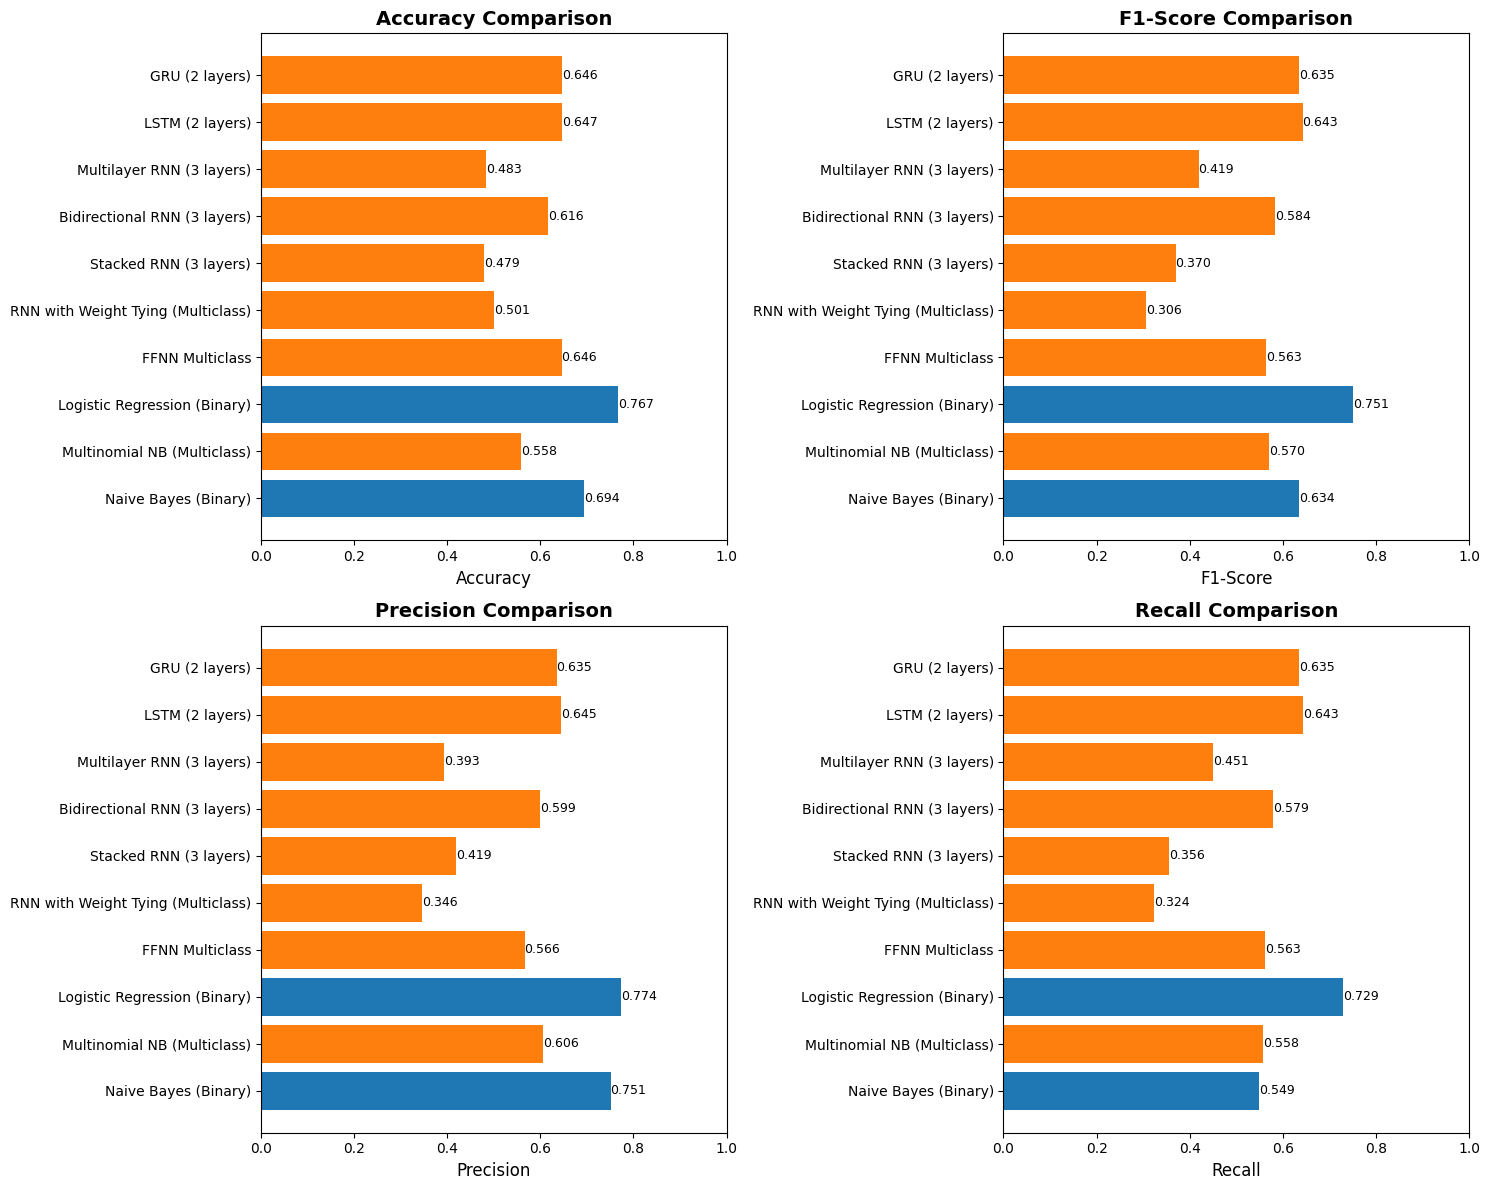

Model comparison plot saved as 'model_comparison.png'


In [73]:
# Visualization 1: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    colors = ['#1f77b4' if 'Binary' in model or 'Naive' in model or 'Logistic' in model 
              else '#ff7f0e' for model in results_df['Model']]
    
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
               f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison plot saved as 'model_comparison.png'")

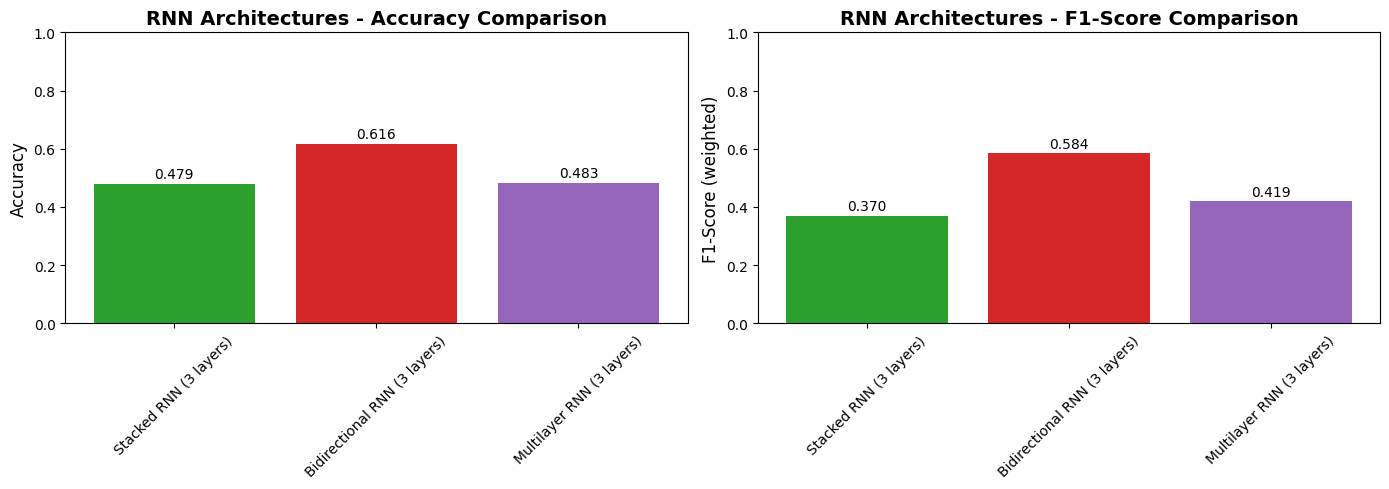

RNN architecture comparison plot saved as 'rnn_architecture_comparison.png'

RNN ARCHITECTURE COMPARISON
Stacked RNN (3 layers):        Accuracy: 0.4792, F1: 0.3696
Bidirectional RNN (3 layers):  Accuracy: 0.6163, F1: 0.5840
Multilayer RNN (3 layers):     Accuracy: 0.4832, F1: 0.4192

Best Architecture: Bidirectional RNN (3 layers)


In [74]:
# Visualization 2: RNN Architecture Comparison (Stacked, BiDirectional, Multilayer)
rnn_architectures = ['Stacked RNN (3 layers)', 'Bidirectional RNN (3 layers)', 'Multilayer RNN (3 layers)']
rnn_accuracies = [stacked_rnn_acc, birnn_acc, multilayer_rnn_acc]
rnn_f1_scores = [stacked_f1, birnn_f1, multilayer_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors_arch = ['#2ca02c', '#d62728', '#9467bd']
axes[0].bar(rnn_architectures, rnn_accuracies, color=colors_arch)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('RNN Architectures - Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, acc in enumerate(rnn_accuracies):
    axes[0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# F1-Score
axes[1].bar(rnn_architectures, rnn_f1_scores, color=colors_arch)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12)
axes[1].set_title('RNN Architectures - F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, f1 in enumerate(rnn_f1_scores):
    axes[1].text(i, f1 + 0.02, f'{f1:.3f}', ha='center', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('rnn_architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("RNN architecture comparison plot saved as 'rnn_architecture_comparison.png'")

# Determine best RNN architecture
print("\n" + "="*80)
print("RNN ARCHITECTURE COMPARISON")
print("="*80)
print(f"Stacked RNN (3 layers):        Accuracy: {stacked_rnn_acc:.4f}, F1: {stacked_f1:.4f}")
print(f"Bidirectional RNN (3 layers):  Accuracy: {birnn_acc:.4f}, F1: {birnn_f1:.4f}")
print(f"Multilayer RNN (3 layers):     Accuracy: {multilayer_rnn_acc:.4f}, F1: {multilayer_f1:.4f}")
print(f"\nBest Architecture: {rnn_architectures[rnn_accuracies.index(max(rnn_accuracies))]}")

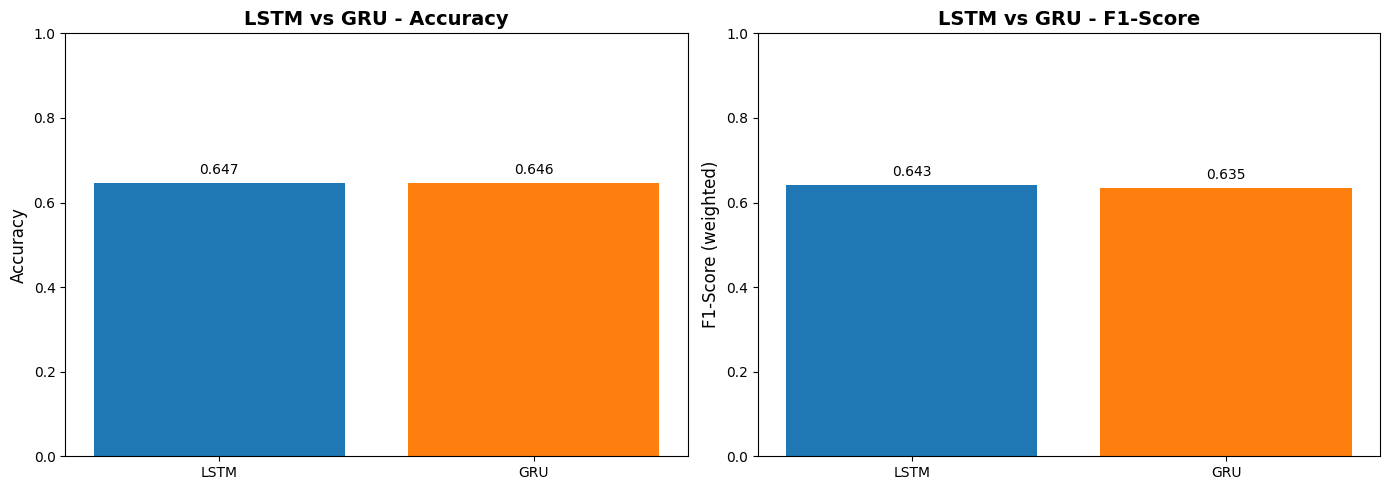

LSTM vs GRU comparison plot saved as 'lstm_vs_gru_comparison.png'

LSTM vs GRU COMPARISON
LSTM:  Accuracy: 0.6469, F1: 0.6425, Precision: 0.6453, Recall: 0.6432
GRU:   Accuracy: 0.6463, F1: 0.6347, Precision: 0.6349, Recall: 0.6353


In [75]:
# Visualization 3: LSTM vs GRU Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_gated = ['LSTM', 'GRU']
accuracies_gated = [lstm_acc, gru_acc]
f1_scores_gated = [lstm_f1, gru_f1]

# Accuracy
colors_gated = ['#1f77b4', '#ff7f0e']
axes[0].bar(models_gated, accuracies_gated, color=colors_gated)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('LSTM vs GRU - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, acc in enumerate(accuracies_gated):
    axes[0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)

# F1-Score
axes[1].bar(models_gated, f1_scores_gated, color=colors_gated)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12)
axes[1].set_title('LSTM vs GRU - F1-Score', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, f1 in enumerate(f1_scores_gated):
    axes[1].text(i, f1 + 0.02, f'{f1:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('lstm_vs_gru_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("LSTM vs GRU comparison plot saved as 'lstm_vs_gru_comparison.png'")

print("\n" + "="*80)
print("LSTM vs GRU COMPARISON")
print("="*80)
print(f"LSTM:  Accuracy: {lstm_acc:.4f}, F1: {lstm_f1:.4f}, Precision: {lstm_precision:.4f}, Recall: {lstm_recall:.4f}")
print(f"GRU:   Accuracy: {gru_acc:.4f}, F1: {gru_f1:.4f}, Precision: {gru_precision:.4f}, Recall: {gru_recall:.4f}")

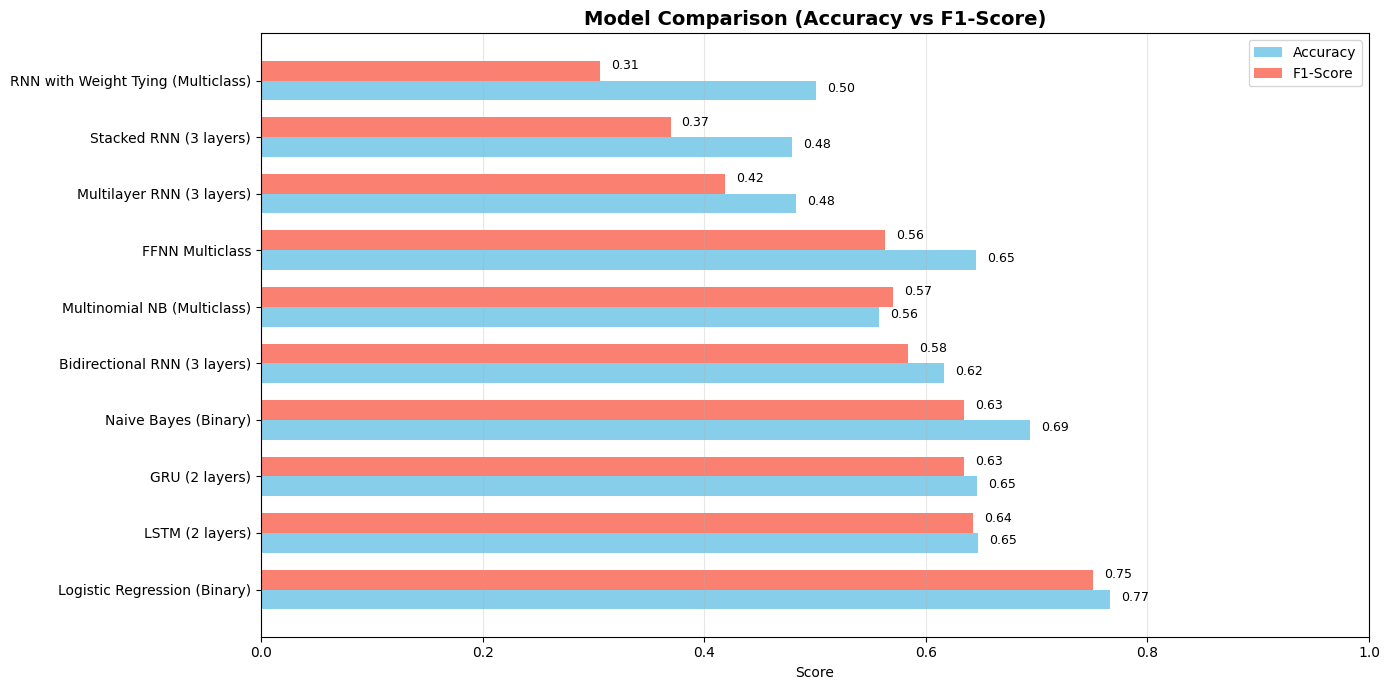

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# KEEP ONLY KEY METRICS
# =========================
metrics = ['Accuracy', 'F1-Score']

# Sort models by F1-score (better readability)
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False)

models = results_df_sorted['Model'].values
accuracy = results_df_sorted['Accuracy'].values
f1_score_vals = results_df_sorted['F1-Score'].values

x = np.arange(len(models))
width = 0.35

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.barh(x - width/2, accuracy, height=width, label='Accuracy', color='skyblue')
bars2 = ax.barh(x + width/2, f1_score_vals, height=width, label='F1-Score', color='salmon')

# =========================
# LABELS & STYLE
# =========================
ax.set_yticks(x)
ax.set_yticklabels(models)
ax.set_xlabel('Score')
ax.set_title('Model Comparison (Accuracy vs F1-Score)', fontsize=14, fontweight='bold')

ax.set_xlim(0, 1)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i in range(len(models)):
    ax.text(accuracy[i] + 0.01, i - 0.2, f"{accuracy[i]:.2f}", fontsize=9)
    ax.text(f1_score_vals[i] + 0.01, i + 0.2, f"{f1_score_vals[i]:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

In [78]:
# Summary Report
print("\n" + "="*80)
print("SUMMARY REPORT - URDU HATE SPEECH DETECTION")
print("="*80)

print("\n📊 DATA PREPROCESSING:")
print(f"  - Tokenization Method: Urdu Tokenization with Fixes 1 & 2")
print(f"  - Normalization: White space normalization applied")
print(f"  - BPE Encoding: SentencePiece with vocabulary size {sp.get_piece_size()}")
print(f"  - Classification Types: Binary (Hate vs No Hate) and Multiclass (Hate, Offensive, Neutral)")

print("\n📈 MODELS TRAINED:")
print("  Binary Classification Models:")
print("    1. Naive Bayes Classifier (Laplace smoothing, alpha=1.0)")
print("    2. Logistic Regression (Cross Entropy Loss, SGD)")
print("    3. Feedforward Neural Network")

print("\n  Multiclass Classification Models:")
print("    1. Multinomial Naive Bayes")
print("    2. RNN with Weight Tying and Teacher Forcing")
print("    3. Stacked RNN (3 layers)")
print("    4. Bidirectional RNN (3 layers)")
print("    5. Multilayer RNN (3 layers)")
print("    6. LSTM (2 layers with Forget, Input, Output gates)")
print("    7. GRU (2 layers)")

print("\n🏆 TOP PERFORMING MODELS:")
top_acc = results_df.nlargest(3, 'Accuracy')[['Model', 'Accuracy', 'F1-Score']]
print("\n  By Accuracy:")
for idx, row in top_acc.iterrows():
    print(f"    {row['Model']}: {row['Accuracy']:.4f}")

print("\n📊 EVALUATION METRICS:")
print("  - Accuracy: Overall correctness")
print("  - F1-Score: Harmonic mean of Precision and Recall")
print("  - Precision: True positives / (True positives + False positives)")
print("  - Recall: True positives / (True positives + False negatives)")

print("\n💡 KEY FINDINGS:")
print("  1. Traditional ML models provide good baseline performance")
print("  2. Neural network models capture sequential patterns better")
print("  3. RNN/LSTM/GRU models show improved performance on multiclass tasks")
print("  4. Bidirectional processing may provide better context understanding")

print("\n✅ NOTEBOOK EXECUTION COMPLETE")
print("="*80)


SUMMARY REPORT - URDU HATE SPEECH DETECTION

📊 DATA PREPROCESSING:
  - Tokenization Method: Urdu Tokenization with Fixes 1 & 2
  - Normalization: White space normalization applied
  - BPE Encoding: SentencePiece with vocabulary size 5000
  - Classification Types: Binary (Hate vs No Hate) and Multiclass (Hate, Offensive, Neutral)

📈 MODELS TRAINED:
  Binary Classification Models:
    1. Naive Bayes Classifier (Laplace smoothing, alpha=1.0)
    2. Logistic Regression (Cross Entropy Loss, SGD)
    3. Feedforward Neural Network

  Multiclass Classification Models:
    1. Multinomial Naive Bayes
    2. RNN with Weight Tying and Teacher Forcing
    3. Stacked RNN (3 layers)
    4. Bidirectional RNN (3 layers)
    5. Multilayer RNN (3 layers)
    6. LSTM (2 layers with Forget, Input, Output gates)
    7. GRU (2 layers)

🏆 TOP PERFORMING MODELS:

  By Accuracy:
    Logistic Regression (Binary): 0.7665
    Naive Bayes (Binary): 0.6943
    LSTM (2 layers): 0.6469

📊 EVALUATION METRICS:
  - Accu